# Resume Ranking System
Word2Vec · SBERT · Hybrid Ensemble · Evaluation

## 1. Imports & Config

In [1]:
import os, re, ast, json, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [22]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE       = "/Users/prabinrimal/Desktop/New>>>>>/roughhhhhh"
MODEL_DIR  = os.path.join(BASE, "test_models")
VECTOR_DIR = os.path.join(BASE, "test_vectors")
OUTPUT_DIR = os.path.join(BASE, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
TOP_K               = 10
SBERT_WEIGHT        = 0.60
W2V_WEIGHT          = 0.40
RELEVANCE_THRESHOLD = 0.60    # score >= this → relevant
CHUNK_SIZE          = 200
CHUNK_STRIDE        = 150

print("Config ready")

Config ready


## 2. Load Models & Saved Vectors

In [23]:
w2v_model   = Word2Vec.load(os.path.join(MODEL_DIR, "word2vec.model"))
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

w2v_matrix   = np.load(os.path.join(VECTOR_DIR, "resume_vectors_w2v.npy"))
sbert_matrix = np.load(os.path.join(VECTOR_DIR, "resume_vectors_sbert.npy"))

with open(os.path.join(VECTOR_DIR, "resume_metadata_w2v.json"))   as f: w2v_meta   = json.load(f)
with open(os.path.join(VECTOR_DIR, "resume_metadata_sbert.json")) as f: sbert_meta = json.load(f)

w2v_df   = pd.DataFrame(w2v_meta)
sbert_df = pd.DataFrame(sbert_meta)

print(f"W2V   matrix : {w2v_matrix.shape}")
print(f"SBERT matrix : {sbert_matrix.shape}")

W2V   matrix : (1429, 150)
SBERT matrix : (1429, 384)


## 3. JD Input & Preprocessing
Paste your Job Description in `RAW_JD`. The same cleaning used on resumes is applied here.

In [24]:
RAW_JD = """
We are seeking a Backend Developer specializing in the Django framework to build scalable web applications.
You will design clean relational database schemas, manage complex ORM queries, and architect robust REST APIs.
Daily tasks include writing modular server-side logic and implementing secure user authentication protocols.
You will collaborate closely with frontend teams to seamlessly integrate user-facing components with backend architectures.
A strong understanding of web server configuration, application caching strategies, and Git workflows is highly essential.
Finally, you will write comprehensive unit tests to ensure high code quality, system security, and performance."""

In [ ]:
def base_clean(text):
    text = "".join(ch for ch in str(text)
                   if ch in "\n\r\t" or (not unicodedata.category(ch).startswith("C") and ch.isprintable()))
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ── SBERT: light clean only (preserves sentence structure) ───────────────────
def clean_for_sbert(text):
    text = base_clean(text)
    text = re.sub(r"[•▪◦‣➤→✓|]", " ", text)
    text = re.sub(r"[^\w\s.,;:\-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# ── Word2Vec: tokenise + stopword removal + lemmatise ─────────────────────────
_stops = set(stopwords.words("english"))
_lemma = WordNetLemmatizer()

def clean_for_w2v(text):
    text = base_clean(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = word_tokenize(text)
    words = [_lemma.lemmatize(w) for w in words if w not in _stops and len(w) > 2]
    return words

jd_sbert_text  = clean_for_sbert(RAW_JD)
jd_w2v_tokens  = clean_for_w2v(RAW_JD)
print(f"SBERT text length : {len(jd_sbert_text.split())} words")
print(f"W2V token count   : {len(jd_w2v_tokens)} tokens")

SBERT text length : 92 words
W2V token count   : 71 tokens


## 4. Encode JD

In [26]:
# ── SBERT: sliding-window chunking (matches resume encoding) ─────────────────
def encode_sbert(text):
    words = text.split()
    if len(words) <= CHUNK_SIZE:
        chunks = [text]
    else:
        chunks, i = [], 0
        while i < len(words):
            chunks.append(" ".join(words[i:i + CHUNK_SIZE]))
            if i + CHUNK_SIZE >= len(words): break
            i += CHUNK_STRIDE
    vecs = sbert_model.encode(chunks, convert_to_numpy=True, normalize_embeddings=True)
    vec  = vecs.mean(axis=0)
    return vec / (np.linalg.norm(vec) or 1)

# ── Word2Vec: IDF-weighted mean pooling ──────────────────────────────────────
def build_idf(corpus):
    N, counts = len(corpus), {}
    for doc in corpus:
        for t in set(doc):
            counts[t] = counts.get(t, 0) + 1
    return {t: np.log((N + 1) / (c + 1)) + 1 for t, c in counts.items()}

corpus = w2v_df["tokens_str"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else x.split()
).tolist()
idf = build_idf(corpus)

def encode_w2v(tokens):
    vecs = [(w2v_model.wv[t], idf.get(t, 1.0)) for t in tokens if t in w2v_model.wv]
    if not vecs: return np.zeros(w2v_model.vector_size)
    vs, ws = zip(*vecs)
    ws = np.array(ws); ws /= ws.sum()
    return np.average(vs, axis=0, weights=ws)

jd_sbert_vec = encode_sbert(jd_sbert_text)
jd_w2v_vec   = encode_w2v(jd_w2v_tokens)

print(f"JD SBERT vector : {jd_sbert_vec.shape}")
print(f"JD W2V   vector : {jd_w2v_vec.shape}")

JD SBERT vector : (384,)
JD W2V   vector : (150,)


## 5. Individual Rankings — Top-10

In [27]:
def top_k_resumes(jd_vec, matrix, meta_df, score_col):
    scores = cosine_similarity(jd_vec.reshape(1, -1), matrix)[0]
    df = meta_df[["resume_id", "category"]].copy()
    df[score_col] = scores
    return df.sort_values(score_col, ascending=False).head(TOP_K).reset_index(drop=True)

sbert_top = top_k_resumes(jd_sbert_vec, sbert_matrix, sbert_df, "sbert_score")
w2v_top   = top_k_resumes(jd_w2v_vec,   w2v_matrix,   w2v_df,   "w2v_score")

sbert_top.index += 1
w2v_top.index   += 1

print("\n── SBERT Top-10 ──")
print(sbert_top.to_string())
print("\n── Word2Vec Top-10 ──")
print(w2v_top.to_string())


── SBERT Top-10 ──
    resume_id              category  sbert_score
1        1202      Python Developer     0.738807
2        1179      Python Developer     0.702675
3        1208      Python Developer     0.678792
4        1206      Python Developer     0.678173
5        1195      Python Developer     0.660333
6        1120  Mobile App Developer     0.651619
7        1173      Python Developer     0.651343
8        1193      Python Developer     0.629136
9        1096  MERN Stack Developer     0.625487
10        733  Full Stack Developer     0.625226

── Word2Vec Top-10 ──
    resume_id              category  w2v_score
1         706  Full Stack Developer   0.957001
2        1099  MERN Stack Developer   0.954788
3        1202      Python Developer   0.949133
4        1428     Software Engineer   0.947719
5         668  Full Stack Developer   0.947313
6        1057  MERN Stack Developer   0.945889
7        1385     Software Engineer   0.945499
8         666  Full Stack Developer   0.94

## 6. Hybrid Ranking — Weighted Ensemble

In [ ]:
# Compute scores over FULL corpus, normalise, then combine
all_sbert = cosine_similarity(jd_sbert_vec.reshape(1, -1), sbert_matrix)[0]
all_w2v   = cosine_similarity(jd_w2v_vec.reshape(1, -1),   w2v_matrix)[0]

combined = sbert_df[["resume_id", "category"]].copy()
combined["sbert_score"] = all_sbert
combined = combined.merge(w2v_df[["resume_id"]].assign(w2v_score=all_w2v), on="resume_id", how="left")
combined["w2v_score"].fillna(0, inplace=True)

combined["hybrid_score"] = SBERT_WEIGHT * combined["sbert_score"] + W2V_WEIGHT * combined["w2v_score"]

hybrid_top = combined.sort_values("hybrid_score", ascending=False).head(TOP_K).reset_index(drop=True)
hybrid_top.index += 1

print(f"── Hybrid Top-10  (SBERT×{SBERT_WEIGHT} + W2V×{W2V_WEIGHT}) ──")
print(hybrid_top[["resume_id", "category", "sbert_score", "w2v_score", "hybrid_score"]].to_string())

── Hybrid Top-10  (SBERT×0.6 + W2V×0.4) ──
    resume_id              category  sbert_score  w2v_score  hybrid_score
1        1202      Python Developer     0.738807   0.949133      0.822937
2        1179      Python Developer     0.702675   0.940477      0.797796
3        1208      Python Developer     0.678792   0.900015      0.767281
4        1206      Python Developer     0.678173   0.891258      0.763407
5        1195      Python Developer     0.660333   0.913574      0.761629
6        1193      Python Developer     0.629136   0.938366      0.752828
7        1120  Mobile App Developer     0.651619   0.901559      0.751595
8        1438     Software Engineer     0.624522   0.932718      0.747801
9        1173      Python Developer     0.651343   0.874325      0.740536
10        733  Full Stack Developer     0.625226   0.912873      0.740285


/var/folders/kn/1pxf37f92vgf6mk6v0b9gzcc0000gn/T/ipykernel_16436/1410403532.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  combined["w2v_score"].fillna(0, inplace=True)


## 7. Score Comparison Bar Chart

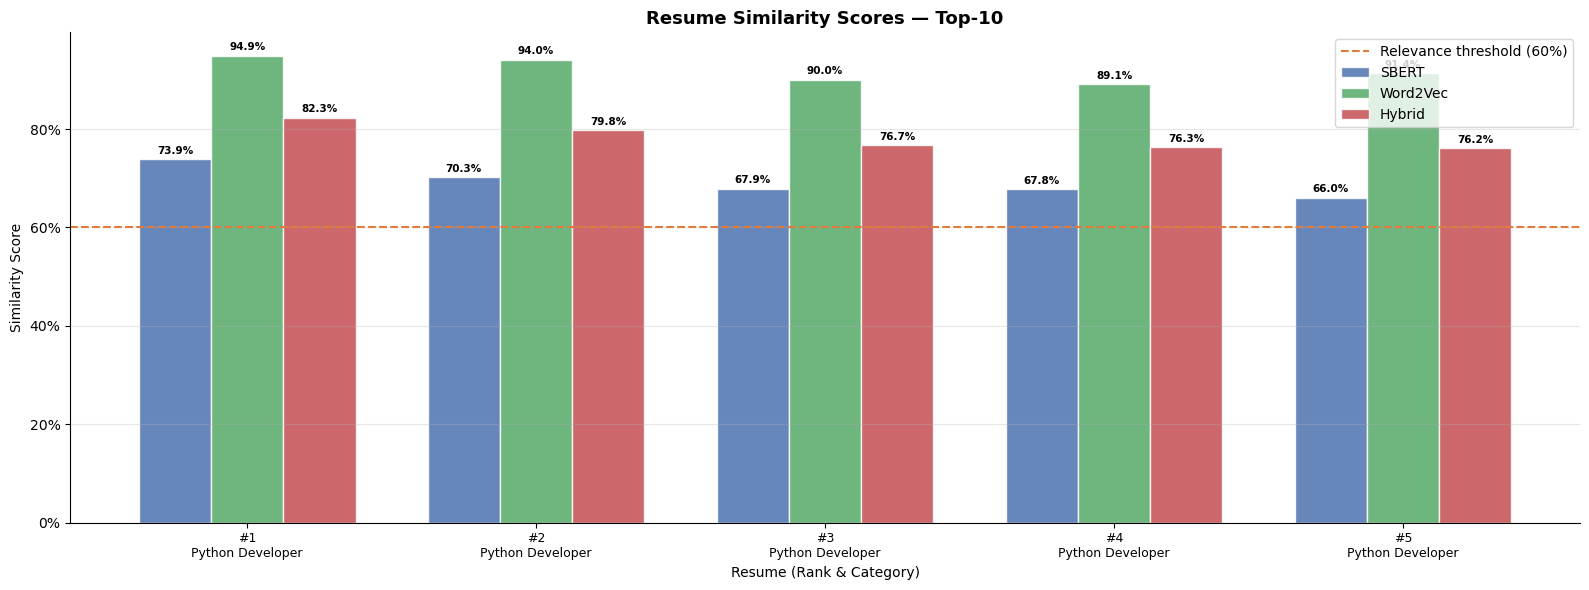

In [29]:
df = hybrid_top.head(5).copy()
labels = [f"#{i}\n{cat[:20]}" for i, cat in zip(df.index, df["category"])]
x, w = np.arange(len(df)), 0.25
fig, ax = plt.subplots(figsize=(16, 6))

for offset, col, color, name in [
    (-w, "sbert_score",  "#4C72B0", "SBERT"),
    ( 0, "w2v_score",    "#55A868", "Word2Vec"),
    ( w, "hybrid_score", "#C44E52", "Hybrid"),
]:
    bars = ax.bar(x + offset, df[col], w, label=name, color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, df[col]):
        ax.text(bar.get_x() + w/2, bar.get_height() + 0.007,
                f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.axhline(RELEVANCE_THRESHOLD, color="#E07B39", linewidth=1.5, linestyle="--",
           label=f"Relevance threshold ({RELEVANCE_THRESHOLD:.0%})")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Similarity Score"); ax.set_xlabel("Resume (Rank & Category)")
ax.set_title("Resume Similarity Scores — Top-10", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "score_chart.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Evaluation — Precision@K · MRR · NDCG@K


In [30]:
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd

TARGET_CATEGORY = "Python Developer"
EVAL_K = TOP_K 

def calculate_binary_metrics(df, score_column, target_cat, k=10):
   
    # 1. Generate binary ground-truth array (1 for matching category, 0 otherwise)
    y_true = np.array([1 if cat == target_cat else 0 for cat in df['category']])
    y_score = np.array(df[score_column].values)
    
    # 2. Extract top K indices sorted by model confidence scores descending
    top_k_indices = np.argsort(y_score)[::-1][:k]
    hits_at_k = np.sum(y_true[top_k_indices])
    
    # 3. Calculate Precision@K
    precision_at_k = hits_at_k / k
    
    # 4. Calculate Reciprocal Rank (RR / MRR for this single query track)
    # Sort the entire dataset to find out exactly where the first true match lands
    sorted_all_indices = np.argsort(y_score)[::-1]
    mrr_score = 0.0
    for rank_position, idx in enumerate(sorted_all_indices, start=1):
        if df['category'].iloc[idx] == target_cat:
            mrr_score = 1.0 / rank_position
            break
            
    # 5. Calculate Ranked Information Retrieval Metric (NDCG@K)
    y_true_2d = y_true.reshape(1, -1)
    y_score_2d = y_score.reshape(1, -1)
    ndcg_at_k = ndcg_score(y_true_2d, y_score_2d, k=k)
    
    return precision_at_k, mrr_score, ndcg_at_k

models_to_evaluate = {
    "Word2Vec Local" : "w2v_score",
    "SBERT Semantic" : "sbert_score",
    "Hybrid Ensemble": "hybrid_score"
}

metrics_summary = []
for name, score_col in models_to_evaluate.items():
    p_k, mrr, ndcg_k = calculate_binary_metrics(combined, score_col, TARGET_CATEGORY, k=EVAL_K)
    
    metrics_summary.append({
        "Retrieval Strategy": name,
        f"Precision@{EVAL_K}": f"{p_k * 100:.2f}%",
        "MRR": f"{mrr * 100:.2f}%",
        f"NDCG@{EVAL_K}": f"{ndcg_k * 100:.2f}%"
    })

# Render performance stats into a clean summary presentation frame
df_eval_matrix = pd.DataFrame(metrics_summary)
print(f"\n─── SYSTEM PERFORMANCE MATRIX (Target Domain: '{TARGET_CATEGORY}') ───")
print(df_eval_matrix.to_string(index=False))


─── SYSTEM PERFORMANCE MATRIX (Target Domain: 'Python Developer') ───
Retrieval Strategy Precision@10     MRR NDCG@10
    Word2Vec Local       10.00%  33.33%  11.00%
    SBERT Semantic       70.00% 100.00%  79.17%
   Hybrid Ensemble       70.00% 100.00%  79.36%


## 10. Final Ranking Table

In [31]:
out = hybrid_top[["resume_id", "category", "sbert_score", "w2v_score", "hybrid_score"]].copy()
out.index.name = "Rank"
for col in ["sbert_score", "w2v_score", "hybrid_score"]:
    out[col] = out[col].apply(lambda v: f"{v*100:.2f}%")
out.columns = ["Resume ID", "Category", "SBERT", "Word2Vec", "Hybrid"]

print(out.to_string())
out.to_csv(os.path.join(OUTPUT_DIR, "final_ranking.csv"))
print("\nSaved → final_ranking.csv")

      Resume ID              Category   SBERT Word2Vec  Hybrid
Rank                                                          
1          1202      Python Developer  73.88%   94.91%  82.29%
2          1179      Python Developer  70.27%   94.05%  79.78%
3          1208      Python Developer  67.88%   90.00%  76.73%
4          1206      Python Developer  67.82%   89.13%  76.34%
5          1195      Python Developer  66.03%   91.36%  76.16%
6          1193      Python Developer  62.91%   93.84%  75.28%
7          1120  Mobile App Developer  65.16%   90.16%  75.16%
8          1438     Software Engineer  62.45%   93.27%  74.78%
9          1173      Python Developer  65.13%   87.43%  74.05%
10          733  Full Stack Developer  62.52%   91.29%  74.03%

Saved → final_ranking.csv
